In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
import os
import heapq
import memory_profiler

/home/UR/coelhrod/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
class TreeNode:
    def __init__(self, level, V, W, taken, upper_bound=None):
        self.level = level
        self.V = V  # Valor da solução
        self.W = W  # Peso da solução
        self.taken = taken  # Lista de índices dos itens escolhidos
        self.upper_bound = upper_bound  # Limite superior

    def __lt__(self, other):
        return (self.upper_bound or 0) > (other.upper_bound or 0)  # Maior upper_bound tem prioridade

class KPBB_BestFirst:
    def __init__(self, values, weights, cap): 
        self.capacity = cap
        self.values = values
        self.weights = weights
        self.ordered = sorted(
            [((v, w), i) for i, (v, w) in enumerate(zip(values, weights))], 
            key=lambda tup: float(tup[0][0]) / tup[0][1], 
            reverse=True
        )
    
    def UpperBound(self, node):
        W = self.capacity - node.W
        result = node.V
        i = node.level + 1

        while i < len(self.ordered) and self.ordered[i][0][1] <= W:
            W -= self.ordered[i][0][1]
            result += self.ordered[i][0][0]
            i += 1
        
        if i < len(self.ordered):
            result += self.ordered[i][0][0] * (W / self.ordered[i][0][1])
        return result

    def solve(self):
        root = TreeNode(-1, 0, 0, [], self.UpperBound(TreeNode(-1, 0, 0, [], 0)))
        queue = []
        heapq.heappush(queue, root)

        self.bestValue = 0
        self.bestTaken = []

        while queue:
            node = heapq.heappop(queue)

            if node.upper_bound <= self.bestValue:
                continue

            if node.level < len(self.ordered) - 1:
                item = self.ordered[node.level + 1]
                nodeRight = TreeNode(
                    node.level + 1, node.V + item[0][0], node.W + item[0][1], 
                    node.taken + [item[1]], self.UpperBound(node)
                )
                
                if nodeRight.W <= self.capacity and nodeRight.V > self.bestValue:
                    self.bestValue = nodeRight.V
                    self.bestTaken = nodeRight.taken

                if nodeRight.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeRight)

                nodeLeft = TreeNode(node.level + 1, node.V, node.W, node.taken, self.UpperBound(node))
                
                if nodeLeft.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeLeft)

        # Converter lista de índices para array binário
        best_solution = [1 if i in self.bestTaken else 0 for i in range(len(self.values))]
        return best_solution, self.bestValue


def knapsack_BU(values, weights, W):
    W = int(W)
    n = len(values)

    dp = [[0] * (W + 1) for _ in range(n + 1)]
    selected = [[[] for _ in range(W + 1)] for _ in range(n + 1)]  # Para armazenar os itens escolhidos

    for i in range(n):
        wi = int(weights[i])

        for x in range(W + 1):
            dp[i + 1][x] = dp[i][x]
            selected[i + 1][x] = selected[i][x]  # Mantém a escolha anterior

            if wi <= x and values[i] + dp[i][x - wi] > dp[i + 1][x]:
                dp[i + 1][x] = values[i] + dp[i][x - wi]
                selected[i + 1][x] = selected[i][x - wi] + [i]  # Adiciona o item

    # Reconstrução da solução binária
    best_solution = [1 if i in selected[n][W] else 0 for i in range(n)]
    return best_solution, dp[n][W]


def initial_solution(weights, values, wmax):
    n = len(weights)
    selected = np.zeros(n, dtype=int)
    W = wmax
    result = 0

    indices = np.random.permutation(n)

    for i in indices:
        if W >= weights[i]:
            selected[i] = 1
            W -= weights[i]
            result += values[i]

    return selected, result, W


def knapsack_value(selected, weights, values):
    value = np.dot(selected, values)
    weight = np.dot(selected, weights)
    return value, weight


def get_neighbor(selected, weights, values, wmax):
    neighbor = selected.copy()
    n = len(weights)
    
    num_changes = 1 if n < 50 else np.random.randint(1, min(5, n // 10))

    for _ in range(num_changes):
        i = np.random.randint(n)
        neighbor[i] = 1 - neighbor[i]

    new_value, new_weight = knapsack_value(neighbor, weights, values)

    if new_weight > wmax:
        neighbor = selected.copy()
        new_value, new_weight = knapsack_value(neighbor, weights, values)

    return neighbor, new_value, new_weight


def simulated_annealing_knapsack(values, weights, wmax, T0=100, coeff=0.99, iter_step=100, stop_threshold=0.001):
    current_solution, current_value, current_weight = initial_solution(weights, values, wmax)
    best_solution = current_solution.copy()
    best_value = current_value
    T = T0

    while T > stop_threshold:
        nb_moves = 0
        for _ in range(iter_step):
            new_solution, new_value, new_weight = get_neighbor(current_solution, weights, values, wmax)
            
            delta = new_value - current_value

            if delta > 0 or np.random.rand() < np.exp(delta / T):
                current_solution = new_solution.copy()
                current_value = new_value
                current_weight = new_weight
                nb_moves += 1

                if current_value > best_value:
                    best_solution = current_solution.copy()
                    best_value = current_value

        acceptance_rate = nb_moves / iter_step if iter_step > 0 else 0
        if acceptance_rate < stop_threshold:
            break
        T *= coeff

    return best_solution, best_value


## Exercice 1 – Algorithme Génétique pour le problème du sac à dos 0/1
On vous demande dans cet exercice de programmer un algorithme génétique pour résoudre le problème du sac à dos 0/1. Vous testerez votre algorithme sur les données fournies lors des séances précédentes. Vous comparerez statistiquement (donc en faisant de multiples run de votre algorithme, ce qui est indispensable quand l’aléatoire intervient) les résultats de votre algorithme avec ceux obtenus par les méthodes concurrentes. Vous pourrez également analyser l’impact des différents paramètres de l’algorithme.

In [9]:
def knapsack_genetic(values, weights, W, pop_size=100, generations=500, mutation_rate=0.05, tournament_size=5):
    num_items = len(values)

    def fitness(individual):
        """Calcula o valor da mochila e penaliza soluções inválidas."""
        total_value = np.dot(individual, values)
        total_weight = np.dot(individual, weights)
        return total_value if total_weight <= W else 0

    def selection(population):
        """Seleciona um indivíduo via torneio."""
        indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament = population[indices]
        return max(tournament, key=fitness)

    def crossover(parent1, parent2):
        """Crossover de um ponto único."""
        point = np.random.randint(1, num_items)
        child = np.concatenate((parent1[:point], parent2[point:]))
        return child

    def mutation(individual):
        """Mutação bit a bit."""
        for i in range(num_items):
            if np.random.rand() < mutation_rate:
                individual[i] = 1 - individual[i]
        return individual

    def generate_valid_solution():
        """Gera uma solução inicial válida."""
        while True:
            candidate = np.random.randint(2, size=num_items)
            if np.dot(candidate, weights) <= W:
                return candidate

    # Inicializa a população com soluções válidas
    population = np.array([generate_valid_solution() for _ in range(pop_size)])

    # Evolução
    for _ in range(generations):
        new_population = []
        for _ in range(pop_size):
            parent1 = selection(population)
            parent2 = selection(population)
            child = crossover(parent1, parent2)
            child = mutation(child)

            # Se a solução for inválida, descarta e usa um pai como fallback
            if np.dot(child, weights) > W:
                child = parent1 if fitness(parent1) > fitness(parent2) else parent2

            new_population.append(child)

        population = np.array(new_population)

    # Melhor indivíduo final
    best_individual = max(population, key=fitness)
    return best_individual, fitness(best_individual)

In [48]:
def knapsack_genetic(values, weights, W, pop_size=100, generations=10000, mutation_rate=0.01, tournament_size=5):
    num_items = len(values)

    def fitness(individual):
        """Calcula o valor da mochila e penaliza se ultrapassar o peso máximo."""
        total_value = np.dot(individual, values)
        total_weight = np.dot(individual, weights)
        return total_value if total_weight <= W else 0  # Penaliza soluções inválidas

    def selection(population):
        """Seleciona um indivíduo pelo método de torneio."""
        indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament = population[indices]
        return max(tournament, key=fitness)

    def crossover(parent1, parent2):
        """Crossover de um ponto."""
        point = np.random.randint(1, num_items)
        child = np.concatenate((parent1[:point], parent2[point:]))
        return child

    def mutation(individual):
        """Aplica mutação bit a bit."""
        for i in range(num_items):
            if np.random.rand() < mutation_rate:
                individual[i] = 1 - individual[i]  # Inverte o bit
        return individual

    # Inicialização da população
    population = np.random.randint(2, size=(pop_size, num_items))

    # Evolução da população
    for _ in range(generations):
        new_population = []
        for _ in range(pop_size):
            parent1 = selection(population)
            parent2 = selection(population)
            child = crossover(parent1, parent2)
            child = mutation(child)
            new_population.append(child)
        population = np.array(new_population)

    # Escolher a melhor solução final
    print(population)
    print(fitness(population[0]))
    best_individual = max(population, key=fitness)
    return fitness(best_individual), best_individual

In [10]:
values = [60, 100, 120]
weights = [10, 20, 30]
W = 50
bestTaken, bestValue = knapsack_genetic(values, weights, W)
print(bestValue)
print(bestTaken)

220
[0 1 1]


### Single Test

In [12]:
path = "./instances_01_KP/low-dimensional/f10_l-d_kp_20_879" 
dataset = np.loadtxt(path)

n = int(dataset[0][0])
wmax = dataset[0][1]
itens = dataset[1:]

weights = dataset[1:,1]
values = dataset[1:,0]

print(weights)
print(values)

[84. 83. 43.  4. 44.  6. 82. 92. 25. 83. 56. 18. 58. 14. 48. 70. 96. 32.
 68. 92.]
[91. 72. 90. 46. 55.  8. 35. 75. 61. 15. 77. 40. 63. 75. 29. 75. 17. 78.
 40. 44.]


In [16]:
methods = {
    "Genetic Algorithm": knapsack_genetic,
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    "B&B Best First": KPBB_BestFirst
}

times = {method: [] for method in methods}
memory_usages = {method: [] for method in methods}
n_values = []

for method_name, method in methods.items():
    tic = time.perf_counter()
    mem_before = memory_profiler.memory_usage()[0]

    if method_name == "Genetic Algorithm" or method_name == "Simulated Annealing":
        bestTaken, bestValue = method(values, weights, wmax)  
        print(f"{method_name}, Estimated Best value:", bestValue)
    elif method_name == "Bottom-Up":
        bestTaken, bestValue = method(values, weights, wmax)  
        print(f"{method_name}, Optimal value:", bestValue)
    else:
        knapsack_solver = method(values, weights, wmax)
        bestTaken, bestValue = knapsack_solver.solve()
        print(f"{method_name}, Optimal value:", bestValue)

    mem_after = memory_profiler.memory_usage()[0]
    toc = time.perf_counter()

    # Armazenar tempo e memória
    times[method_name].append(toc - tic)
    memory_usages[method_name].append(mem_after - mem_before)

    print(f"Time: {(toc - tic):.4f}s | Memory: {(mem_after - mem_before):.4f} MB\n")
    

n_values.append(n)

Genetic Algrithm, Estimated Best value: 1025.0
Time: 2.1504s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 1025.0
Time: 0.6849s | Memory: 0.0000 MB

Bottom-Up, Optimal value: 1025.0
Time: 0.2224s | Memory: 0.0000 MB

B&B Best First, Optimal value: 1025.0
Time: 0.2032s | Memory: 0.0000 MB



### Low Dimensional

In [15]:
datasets = []
listing = os.listdir("./instances_01_KP/low-dimensional/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    path = "./instances_01_KP/low-dimensional/" + infile
    data = np.loadtxt(path)
    datasets.append(data)


=== Problem with 15 items and 375 capacity ===
Genetic Algorithm, Estimated Best value: 481.06936799999994
Genetic Algorithm - Time: 2.0687s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 481.06936799999994
Simulated Annealing - Time: 0.7466s | Memory: 0.0000 MB

Bottom-Up, Optimal value: 481.069368
Bottom-Up - Time: 0.2094s | Memory: 0.2500 MB

B&B Best First, Optimal value: 481.069368
B&B Best First - Time: 0.2024s | Memory: 0.0000 MB


=== Problem with 10 items and 269 capacity ===
Genetic Algorithm, Estimated Best value: 295.0
Genetic Algorithm - Time: 1.9957s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 295.0
Simulated Annealing - Time: 0.7357s | Memory: 0.0000 MB

Bottom-Up, Optimal value: 295.0
Bottom-Up - Time: 0.2330s | Memory: 0.0000 MB

B&B Best First, Optimal value: 295.0
B&B Best First - Time: 0.2013s | Memory: 0.0000 MB


=== Problem with 10 items and 60 capacity ===
Genetic Algorithm, Estimated Best value: 52.0
Genetic Algorithm - Tim

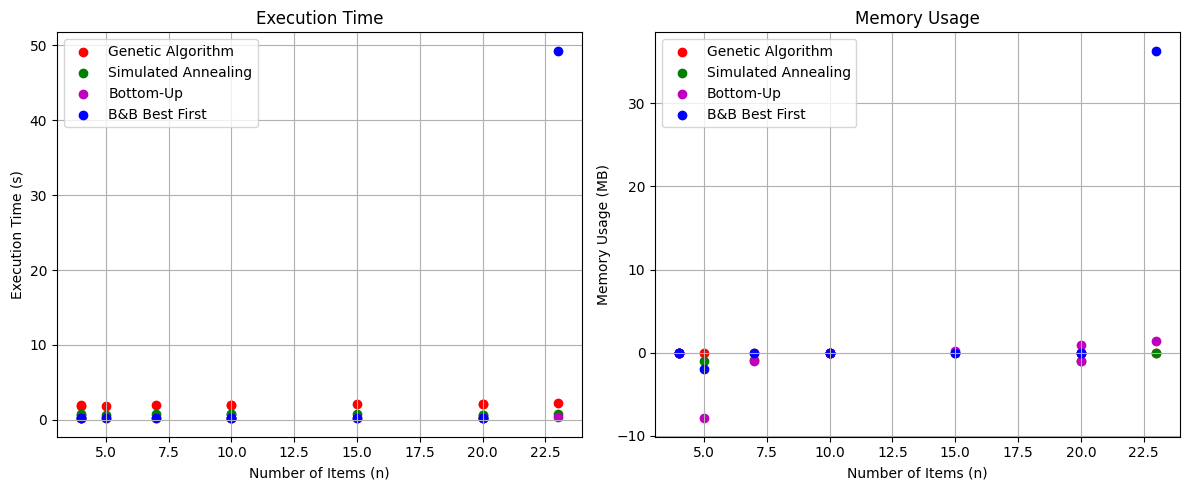

In [23]:
methods = {
    "Genetic Algorithm": knapsack_genetic,
    "Simulated Annealing": simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    "B&B Best First": KPBB_BestFirst
}

times = {method: [] for method in methods}
memory_usages = {method: [] for method in methods}
n_values = []

for dataset in datasets:
    n = int(dataset[0][0])
    wmax = dataset[0][1] 
    itens = dataset[1:]
    weights = dataset[1:, 1]
    values = dataset[1:, 0]

    print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")

    for method_name, method in methods.items():
        # Medir tempo e memória
        tic = time.perf_counter()
        mem_before = memory_profiler.memory_usage()[0]

        if method_name == "Genetic Algorithm" or method_name == "Simulated Annealing":
            bestTaken, bestValue = method(values, weights, wmax)  
            print(f"{method_name}, Estimated Best value:", bestValue)
        elif method_name == "Bottom-Up":
            bestTaken, bestValue = method(values, weights, wmax)  
            print(f"{method_name}, Optimal value:", bestValue)
        else:
            knapsack_solver = method(values, weights, wmax)
            bestTaken, bestValue = knapsack_solver.solve()
            print(f"{method_name}, Optimal value:", bestValue)

        mem_after = memory_profiler.memory_usage()[0]
        toc = time.perf_counter()

        # Armazenar tempo e memória
        times[method_name].append(toc - tic)
        memory_usages[method_name].append(mem_after - mem_before)

        print(f"Time: {(toc - tic):.4f}s | Memory: {(mem_after - mem_before):.4f} MB\n")

    n_values.append(n)

# Plot execution times
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['r', 'g', 'm', 'b'] 
for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)
plt.xlabel("Number of Items (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.title("Execution Time")

# Plot memory usage
plt.subplot(1, 2, 2)
for (method_name, method_memory), color in zip(memory_usages.items(), colors):
    plt.scatter(n_values, method_memory, marker='o', linestyle='-', color=color, label=method_name)
plt.xlabel("Number of Items (n)")
plt.ylabel("Memory Usage (MB)")
plt.legend()
plt.grid(True)
plt.title("Memory Usage")

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can again see the effect of a high knapsack capacity value impacting the data visualization.
  </p>
</div>

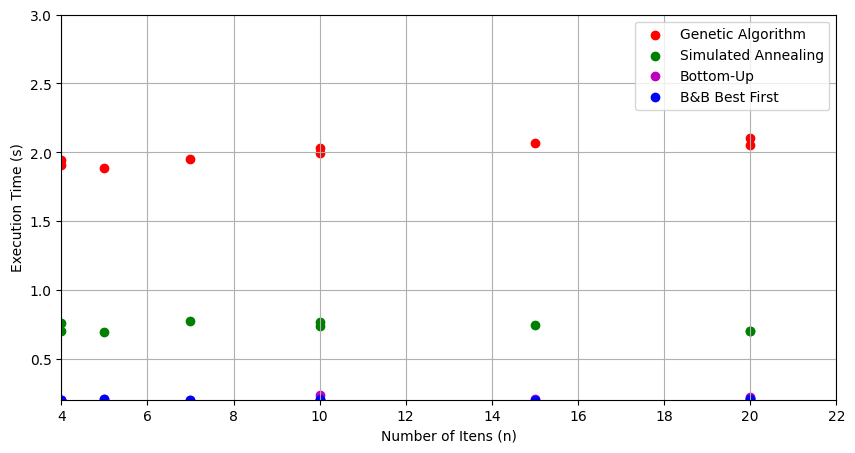

In [24]:
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlim([min(n_values), 22.0])  
plt.ylim([min(method_times), 3])  
plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The Simulated Annealing method proved to be less efficient in the Low Dimensional examples, as the number of iterations required to meet the stopping criterion is large compared to the other methods. It is also important to mention its accuracy: only one trial did not produce an estimated result equal to the optimal result (though it was still a close result), which is very good for a non-exact method.
  </p>
</div>

#### Large Scale

In [31]:
def knapsack_genetic(values, weights, W, pop_size=1000, generations=500, mutation_rate=0.05, tournament_size=5):
    num_items = len(values)

    def fitness(individual):
        """Calcula o valor total e penaliza se ultrapassar o peso máximo."""
        total_value = np.dot(individual, values)
        total_weight = np.dot(individual, weights)
        return total_value if total_weight <= W else total_value * (W / total_weight)  # Penalização

    def selection(population):
        """Seleciona um indivíduo pelo método de torneio."""
        indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament = population[indices]
        return max(tournament, key=fitness)

    def crossover(parent1, parent2):
        """Crossover de um ponto único."""
        point = np.random.randint(1, num_items)
        child = np.concatenate((parent1[:point], parent2[point:]))
        return child

    def mutation(individual):
        """Mutação bit a bit."""
        for i in range(num_items):
            if np.random.rand() < mutation_rate:
                individual[i] = 1 - individual[i]
        return individual

    def generate_valid_solution():
        """Gera uma solução válida somando itens até atingir W."""
        indices = np.argsort(weights)  # Ordena pelos pesos
        solution = np.zeros(num_items, dtype=int)
        total_weight = 0
        for i in indices:
            if total_weight + weights[i] <= W:
                solution[i] = 1
                total_weight += weights[i]
        return solution

    # Inicializa a população com soluções válidas
    population = np.array([generate_valid_solution() for _ in range(pop_size)])

    # Evolução
    for _ in range(generations):
        new_population = []
        for _ in range(pop_size):
            parent1 = selection(population)
            parent2 = selection(population)
            child = crossover(parent1, parent2)
            child = mutation(child)

            # Corrige soluções inválidas removendo itens pesados aleatoriamente
            while np.dot(child, weights) > W:
                ones = np.where(child == 1)[0]  # Itens selecionados
                if len(ones) == 0:
                    break  # Evita loop infinito
                child[np.random.choice(ones)] = 0  # Remove um item aleatório

            new_population.append(child)

        population = np.array(new_population)

    # Melhor indivíduo final
    best_individual = max(population, key=fitness)
    return best_individual, fitness(best_individual) 

In [33]:
datasets = []
N_values = []
W_values = []
listing = os.listdir("./instances_01_KP/large_scale/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    print(infile)
    path = os.path.join("./instances_01_KP/large_scale/", infile)
    # path = os.path.join("./instances_01_KP/large_scale/knapPI_1_200_1000_1")
    
    parts = infile.split("_")
    N = int(parts[2])  
    W = int(parts[3])  
    
    N_values.append(N)
    W_values.append(W)

    with open(path, "r") as f:
        lines = f.readlines()[:-1]  
    
    data = np.loadtxt(lines)
    datasets.append(data)
    # break
    

knapPI_1_200_1000_1
knapPI_3_2000_1000_1
knapPI_3_1000_1000_1
knapPI_2_200_1000_1
knapPI_3_5000_1000_1
knapPI_2_1000_1000_1
knapPI_3_500_1000_1
knapPI_2_5000_1000_1
knapPI_3_100_1000_1
knapPI_1_2000_1000_1
knapPI_3_200_1000_1
knapPI_2_10000_1000_1
knapPI_1_10000_1000_1
knapPI_1_500_1000_1
knapPI_2_2000_1000_1
knapPI_1_5000_1000_1
knapPI_2_100_1000_1
knapPI_2_500_1000_1
knapPI_1_100_1000_1
knapPI_1_1000_1000_1
knapPI_3_10000_1000_1


In [34]:
methods = {
    "Genetic Algorithm": knapsack_genetic,
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    # "B&B Best First": KPBB_BestFirst
}

# Dic to store exec times
times = {method: [] for method in methods}
n_values = []

for dataset in datasets:
    n = dataset[0][0] 
    wmax = dataset[0][1]
    itens = dataset[1:]
    weights = dataset[1:, 1]
    values = dataset[1:, 0]

    print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")
    
    for method_name, method in methods.items():

        tic = time.perf_counter()
        mem_before = memory_profiler.memory_usage()[0]

        if method_name == "Genetic Algorithm" or method_name == "Simulated Annealing":
            bestTaken, bestValue = method(values, weights, wmax)  
            print(f"{method_name}, Estimated Best value:", bestValue)
        elif method_name == "Bottom-Up":
            bestTaken, bestValue = method(values, weights, wmax)  
            print(f"{method_name}, Optimal value:", bestValue)
        else:
            knapsack_solver = method(values, weights, wmax)
            bestTaken, bestValue = knapsack_solver.solve()
            print(f"{method_name}, Optimal value:", bestValue)

        mem_after = memory_profiler.memory_usage()[0]
        toc = time.perf_counter()

        # Armazenar tempo e memória
        times[method_name].append(toc - tic)
        memory_usages[method_name].append(mem_after - mem_before)

        print(f"Time: {(toc - tic):.4f}s | Memory: {(mem_after - mem_before):.4f} MB\n")


    n_values.append(n)
    


=== Problem with 200 items and 1008 capacity ===
Genetic Algorithm, Estimated Best value: 3854.0
Time: 81.0018s | Memory: 1.5000 MB

Simulated Annealing, Estimated Best value: 11056.0
Time: 1.3179s | Memory: 0.0000 MB

Bottom-Up, Optimal value: 11238.0
Time: 0.3791s | Memory: 0.0000 MB


=== Problem with 2000 items and 9819 capacity ===
Genetic Algorithm, Estimated Best value: 12709.0
Time: 650.2643s | Memory: 42.5547 MB

Simulated Annealing, Estimated Best value: 20719.0
Time: 1.9794s | Memory: -45.3398 MB

Bottom-Up, Optimal value: 28919.0
Time: 11.0566s | Memory: 865.1055 MB


=== Problem with 1000 items and 4990 capacity ===


KeyboardInterrupt: 

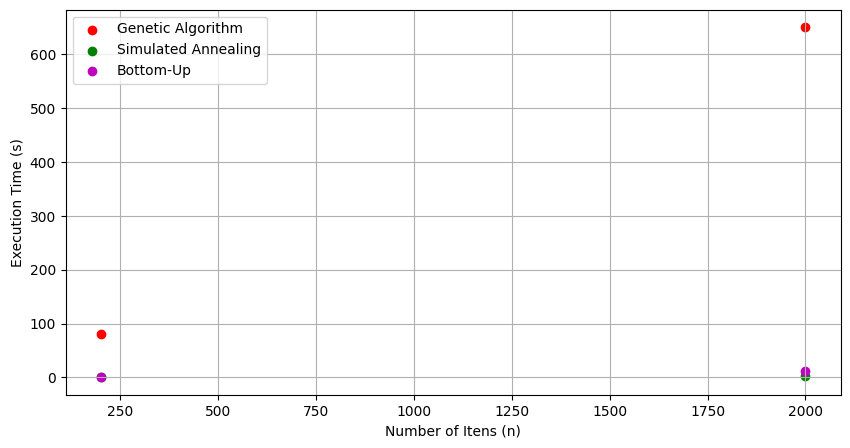

In [35]:
# Plot exec times
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    For the Large Scale examples, the speed of the Simulated Annealing method was slower than the Bottom-Up method starting from 1000 items in the knapsack, as the number of iterations for BU equals the number of items, while the iterations for SA always stay within the same range. However, the estimated results were far from the optimal value, which is unsatisfactory. This may have occurred because the number of items explored is small compared to the number of available items, as the temperature drops too quickly.
  </p>
</div>